# Task 2 — Evasion‑Based Clarity Classification

Fine‑tuning di **Llama 3.1 8B‑Instruct** (4‑bit QLoRA + DoRA) per classificare la tecnica di evasione politica tra 10 sotto‑categorie, poi mappata alle 3 macro‑categorie di chiarezza.

In [4]:
# ============================================================
# CELLA 1 — Setup & Installazione
# ============================================================

# Installazione dipendenze (decommentare su Colab)
# !pip install -q -U transformers peft trl bitsandbytes datasets accelerate

import os, sys, json, gc
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from huggingface_hub import login
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig
from datasets import load_from_disk
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix

try:
    import yaml
except ImportError as exc:
    raise ImportError("Missing dependency: PyYAML. Install with `pip install pyyaml`.") from exc

# Configurazione dei percorsi e rilevamento ambiente (Colab / Locale)
try:
    import google.colab
    from google.colab import drive, userdata
    drive.mount('/content/drive', force_remount=True)

    # Percorsi base su Google Drive
    BASE_DIR = "/content/drive/MyDrive/progettoLLM"
    REPO_DIR = os.path.join(BASE_DIR, "CLARITY")
    hf_cache_dir = os.path.join(BASE_DIR, "hf_cache")
    
    os.makedirs(hf_cache_dir, exist_ok=True)
    os.environ["HF_HOME"] = hf_cache_dir
    
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)

    # Login HF tramite Colab Secrets
    hf_token = userdata.get('HF_TOKEN')
    os.environ['HF_TOKEN'] = hf_token
    login(token=hf_token)
    print(f"Ambiente Google Colab configurato. Cache: {hf_cache_dir}")

except ImportError:
    # Percorsi base in locale
    BASE_DIR = ".."
    REPO_DIR = BASE_DIR
    
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)

    # Lettura del token da file .env locale
    env_path = os.path.join(REPO_DIR, ".env")
    if not os.path.exists(env_path):
        env_path = ".env"
        
    if os.path.exists(env_path):
        with open(env_path) as f:
            for line in f:
                if line.startswith("HF_TOKEN="):
                    hf_token = line.split("=", 1)[1].strip().strip("'\"")
                    os.environ['HF_TOKEN'] = hf_token
                    login(token=hf_token)
                    break
    print("Ambiente locale rilevato.")

print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Ambiente locale rilevato.
Device: NVIDIA GeForce RTX 2080 Ti


In [5]:
# ============================================================
# CELLA 2 — Configurazione e Variabili Globali
# ============================================================

# Config da file
CONFIG_PATH = os.path.join(REPO_DIR, "config", "config.yml")
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f) or {}

# Flag di controllo
ESEGUI_TRAINING = bool(config.get("training", {}).get("enabled", True))

# Modello e percorsi
MODEL_ID = config.get("model", {}).get("id", "meta-llama/Llama-3.2-3B-Instruct")

# 1. Cartella Base per i risultati del Task 2
RES_DIR = os.path.join(REPO_DIR, config.get("paths", {}).get("results_dir", "results"))

TASK2_DIR = os.path.join(REPO_DIR, config.get("paths", {}).get("task2_dir", "results/task2"))

# 2. Percorsi specifici costruiti dinamicamente
OUTPUT_DIR = os.path.join(TASK2_DIR, "checkpoints")
PATH_MODELLO_SALVATO = os.path.join(TASK2_DIR, "modello_finale")
RISULTATI_DIR = os.path.join(TASK2_DIR, "valutazione")

# Training params (Task 2)
TRAINING_CONFIG = config.get("training", {}).get("task2", {})
SEED = config.get("training", {}).get("seed", 42)
PER_DEVICE_TRAIN_BATCH_SIZE = TRAINING_CONFIG.get("batch_size", 4)
GRADIENT_ACCUMULATION_STEPS = TRAINING_CONFIG.get("gradient_accumulation_steps", 2)
NUM_TRAIN_EPOCHS = TRAINING_CONFIG.get("num_train_epochs", 1)
MAX_LENGTH = TRAINING_CONFIG.get("max_length", 512)

# Dataset/augmentation config
DATASET_CONFIG = config.get("dataset", {})
DATASET_USE_AUGMENTED = bool(DATASET_CONFIG.get("use_augmented", False))
AUGMENTATION_NAME = DATASET_CONFIG.get("augmentation", {}).get("name", "none")
AUGMENTATION_PARAMS = DATASET_CONFIG.get("augmentation", {}).get("params", {})

# Precisione: bfloat16 se supportato, altrimenti float16
COMPUTE_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print(f"Compute dtype: {COMPUTE_DTYPE}")

LABELS = ["Ambivalent", "Clear Reply", "Clear Non-Reply"]

# System prompt con le 10 categorie del Task 2
SYSTEM_PROMPT_TASK2 = """Sei un esperto analista di comunicazione politica. Il tuo compito è classificare la risposta del politico alla domanda scegliendo ESATTAMENTE UNA delle seguenti 9 categorie:

1. 'Explicit'
2. 'Declining to answer'
3. 'Claims ignorance'
4. 'Dodging'
5. 'Deflection'
6. 'General'
7. 'Implicit'
8. 'Partial/half-answer'
9. 'Clarification'

Esempi di classificazione (Few-Shot):
Q: "Appoggerà la nuova legge sulle tasse?"
A: "Non sono a conoscenza dei dettagli della legge." -> {"categoria": "Claims ignorance"}

Q: "Cosa pensa dello scandalo del suo partito?"
A: "Dovreste guardare a cosa ha fatto l'opposizione l'anno scorso!" -> {"categoria": "Deflection"}

Q: "Quali misure prenderete per il clima?"
A: "Il clima è importante, faremo del nostro meglio per tutti." -> {"categoria": "General"}

Rispondi ESCLUSIVAMENTE fornendo un oggetto JSON valido contenente la singola chiave "categoria". Non aggiungere formattazione markdown (come ```json), né preamboli o spiegazioni.
"""
print("Configurazione caricata.")

Compute dtype: torch.bfloat16
Configurazione caricata.


In [6]:
# ============================================================
# CELLA 3 — Preparazione Dataset
# ============================================================

from datasets import DatasetDict
from src.data.augmentation import get_augmentation_fn
from src.data.label_utils import build_label_maps

# Caricamento tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Caricamento split train e test utilizzando percorsi assoluti
TRAIN_DATA_PATH = os.path.join(REPO_DIR, DATASET_CONFIG.get("train_path", "dataset/QEvasion/train"))
TEST_DATA_PATH = os.path.join(REPO_DIR, DATASET_CONFIG.get("test_path", "dataset/QEvasion/test"))

train_dataset = load_from_disk(TRAIN_DATA_PATH)
test_dataset  = load_from_disk(TEST_DATA_PATH)
print(f"Train: {len(train_dataset)} esempi | Test: {len(test_dataset)} esempi")

if DATASET_USE_AUGMENTED:
    if "evasion_label" not in train_dataset.column_names:
        print("Augmentation skipped: 'evasion_label' not found in train split.")
    else:
        ds = DatasetDict({"train": train_dataset, "validation": test_dataset, "test": test_dataset})
        label2id, _ = build_label_maps(ds)
        augment_fn = get_augmentation_fn(AUGMENTATION_NAME)
        ds = augment_fn(ds, label2id, **AUGMENTATION_PARAMS)
        train_dataset = ds["train"]
        print(f"Augmentation applied: {AUGMENTATION_NAME}")

def format_prompt_task2(example):
    """Formatta un esempio nel template chat di Llama 3.1 per il Task 2."""
    domanda  = example.get('interview_question', '')
    risposta = example.get('interview_answer', '')
    label    = example.get('evasion_label', 'Explicit')

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT_TASK2},
        {"role": "user",   "content": f"Domanda: {domanda}\nRisposta del politico: {risposta}"},
        {"role": "assistant", "content": str(label)},
    ]
    return {"text": tokenizer.apply_chat_template(messages, tokenize=False)}

# Applica la formattazione solo al train set (il test usa la funzione di inferenza)
formatted_train = train_dataset.map(format_prompt_task2, remove_columns=train_dataset.column_names)

print("\n--- Esempio di prompt formattato ---")
print(formatted_train[0]["text"][:500] + "\n...")

Train: 3448 esempi | Test: 308 esempi
Augmentation applied: random_deletion

--- Esempio di prompt formattato ---
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 12 May 2026

Sei un esperto analista di comunicazione politica. Il tuo compito è classificare la risposta del politico alla domanda scegliendo ESATTAMENTE UNA delle seguenti 9 categorie:

1. 'Explicit'
2. 'Declining to answer'
3. 'Claims ignorance'
4. 'Dodging'
5. 'Deflection'
6. 'General'
7. 'Implicit'
8. 'Partial/half-answer'
9. 'Clarification'

Esempi di classificazione (Few-Shot):
Q
...


In [7]:
# ============================================================
# CELLA 4 — Logica del Modello (Training vs Loading)
# ============================================================

# Pulizia VRAM per evitare OOM
torch.cuda.empty_cache()
gc.collect()

# Heuristic: leave some headroom on GPU and allow CPU offload if needed
if torch.cuda.is_available():
    total_gb = int(torch.cuda.get_device_properties(0).total_memory / (1024 ** 3))
    gpu_gb = max(total_gb - 2, 1)
    MAX_MEMORY = {0: f"{gpu_gb}GiB", "cpu": "64GiB"}
else:
    MAX_MEMORY = {"cpu": "64GiB"}

# Configurazione quantizzazione 4-bit comune
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    llm_int8_enable_fp32_cpu_offload=True,
)

if ESEGUI_TRAINING:
    # ── TRAINING ──────────────────────────────────────────────
    print("Modalità TRAINING attiva.")

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        device_map="auto",
        max_memory=MAX_MEMORY,
        quantization_config=bnb_config,
        torch_dtype=COMPUTE_DTYPE,
    )
    model = prepare_model_for_kbit_training(model)
    
    # [NEW] 1. Abilita il Gradient Checkpointing per risparmiare VRAM
    model.gradient_checkpointing_enable()

    # Configurazione DoRA sui layer di attenzione
    peft_config = LoraConfig(
        r=16, lora_alpha=32,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        lora_dropout=0.05, bias="none",
        task_type="CAUSAL_LM", use_dora=True,
    )
    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    training_args = SFTConfig(           
        output_dir=OUTPUT_DIR,
        
        # 1. Aumentiamo i dati processati in parallelo
        per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
        
        # 2. Riduciamo gli step sequenziali (4 * 2 = 8 effective batch size)
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        
        # 3. Ottimizzatore più veloce
        optim="adamw_8bit",                # Usa questo (o "adamw_torch"). "paged_" è lento.
        
        # 4. Velocizza il passaggio dei dati alla GPU
        dataloader_num_workers=2,          
        
        save_strategy="epoch",
        logging_steps=10,
        learning_rate=2e-4,
        weight_decay=0.001,
        fp16=(COMPUTE_DTYPE == torch.float16),
        bf16=(COMPUTE_DTYPE == torch.bfloat16),
        max_grad_norm=0.3,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        warmup_steps=100,
        group_by_length=True,
        lr_scheduler_type="cosine",
        report_to="none",
        max_length=MAX_LENGTH,
        seed=SEED,
    )

    trainer = SFTTrainer(
        model=model,
        train_dataset=formatted_train,
        args=training_args,
        peft_config=None,          
        processing_class=tokenizer,
        # max_seq_length rimosso da qui!
    )

    print("🚀 Inizio addestramento...")
    trainer.train()

    # Salvataggio adattatori + tokenizer su Drive
    trainer.model.save_pretrained(PATH_MODELLO_SALVATO)
    tokenizer.save_pretrained(PATH_MODELLO_SALVATO)
    print(f"Modello salvato in: {PATH_MODELLO_SALVATO}")

else:
    # ── CARICAMENTO DA CHECKPOINT ─────────────────────────────
    print(f"Caricamento modello base ({MODEL_ID}) in 4-bit...")

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        device_map="auto",
        max_memory=MAX_MEMORY,
        quantization_config=bnb_config,
        torch_dtype=COMPUTE_DTYPE,
    )

    print(f"Applicazione adattatori LoRA da: {PATH_MODELLO_SALVATO}")
    model = PeftModel.from_pretrained(
        base_model, PATH_MODELLO_SALVATO,
        low_cpu_mem_usage=True, device_map="auto",
    )

    # Sovrascriviamo il tokenizer con quello salvato col checkpoint
    tokenizer = AutoTokenizer.from_pretrained(PATH_MODELLO_SALVATO)
    print("Modello e adattatori caricati.")

model.eval()
print(f"Modello in eval mode. Device: {model.device}")

Modalità TRAINING attiva.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 9,404,416 || all params: 3,222,154,240 || trainable%: 0.2919


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


🚀 Inizio addestramento...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
10,2.987000
20,2.781900
30,2.378700
40,1.772900
50,0.662700
60,1.057600
70,1.048700
80,1.006800
90,1.003100
100,0.523600


Modello salvato in: ../results/task2/modello_finale
Modello in eval mode. Device: cuda:0


In [8]:
# ============================================================
# CELLA 5 — Funzioni di Supporto (Inference JSON & Mapping)
# ============================================================
import json
import torch
from collections import Counter

MAPPING_9_CLASSI = {
    "Explicit": "Clear Reply",
    "Declining to answer": "Clear Non-Reply",
    "Claims ignorance": "Clear Non-Reply",
    "Clarification": "Ambivalent",
    "Dodging": "Ambivalent",
    "Deflection": "Ambivalent",
    "General": "Ambivalent",
    "Implicit": "Ambivalent",
    "Partial/half-answer": "Ambivalent"
}
LABELS_9_CLASSI = list(MAPPING_9_CLASSI.keys())
ANNOTATOR_COLUMNS = ["annotator1", "annotator2", "annotator3"]

def get_true_evasion_label(example):
    """Recupera la label Task 2 reale o la ricostruisce dai voti degli annotatori."""
    label = str(example.get('evasion_label', '')).strip()
    if label in LABELS_9_CLASSI:
        return label

    votes = [
        str(example.get(col, '')).strip()
        for col in ANNOTATOR_COLUMNS
        if str(example.get(col, '')).strip() in LABELS_9_CLASSI
    ]
    if not votes:
        return ""

    vote_counts = Counter(votes)
    max_votes = max(vote_counts.values())
    candidates = [label for label, count in vote_counts.items() if count == max_votes]
    if len(candidates) == 1:
        return candidates[0]

    clarity = str(example.get('clarity_label', '')).strip()
    coherent = [label for label in candidates if MAPPING_9_CLASSI.get(label) == clarity]
    return coherent[0] if coherent else candidates[0]

def predici_evasione(example):
    """
    Genera la predizione estraendo la classe direttamente dal testo
    e la mappa automaticamente alla macro-categoria di chiarezza.
    """
    domanda  = example.get('interview_question', '')
    risposta = example.get('interview_answer', '')

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT_TASK2},
        {"role": "user",   "content": f"Domanda: {domanda}\nRisposta: {risposta}"},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Estrazione stringa
    generated_ids = outputs[0][inputs['input_ids'].shape[-1]:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    
    # Fallback di default
    tecnica_predetta = "Dodging"
    
    # --- NUOVA LOGICA DI ESTRAZIONE ---
    # Cerchiamo se una delle 9 categorie è nominata nel testo generato
    for categoria in MAPPING_9_CLASSI.keys():
        if categoria.lower() in raw_output.lower():
            tecnica_predetta = categoria
            break
            
    # Mapping alla macro classe
    macro_clarity = MAPPING_9_CLASSI.get(tecnica_predetta, "Ambivalent")
    
    return tecnica_predetta, macro_clarity, raw_output

# ============================================================
# Sanity check rapido
# ============================================================
print("--- Sanity check (3 esempi) ---")
for i in range(min(3, len(test_dataset))):
    es = test_dataset[i]
    tecnica, clarity, raw = predici_evasione(es)
    vero = str(es.get('clarity_label', '')).strip()
    print(f"[{i+1}] Raw: {raw:40s} \n    → Tecnica: {tecnica:22s} → Clarity: {clarity:15s} (Vera: {vero})\n")

--- Sanity check (3 esempi) ---


/mnt/Shared-Data/Code/github/itsPinguiz/LLMproject/CLARITY/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/mnt/Shared-Data/Code/github/itsPinguiz/LLMproject/CLARITY/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


[1] Raw: Explicit                                 
    → Tecnica: Explicit               → Clarity: Clear Reply     (Vera: Ambivalent)

[2] Raw: General                                  
    → Tecnica: General                → Clarity: Ambivalent      (Vera: Ambivalent)

[3] Raw: General                                  
    → Tecnica: General                → Clarity: Ambivalent      (Vera: Ambivalent)



Valutazione su 308 esempi...


  0%|          | 0/308 [00:00<?, ?it/s]


REPORT PRE-MAPPING — TASK 2 (9 CLASSI EVASION)
                     precision    recall  f1-score   support

           Explicit      0.667     0.177     0.280        79
Declining to answer      0.714     0.455     0.556        11
   Claims ignorance      0.333     0.250     0.286         8
      Clarification      0.333     0.500     0.400         4
            Dodging      0.286     0.066     0.107        61
         Deflection      0.000     0.000     0.000        22
            General      0.213     0.982     0.350        55
           Implicit      0.000     0.000     0.000        61
Partial/half-answer      0.000     0.000     0.000         7

           accuracy                          0.263       308
          macro avg      0.283     0.270     0.220       308
       weighted avg      0.304     0.263     0.188       308


REPORT FINALE — TASK 2 (EVASION → CLARITY)
                 precision    recall  f1-score   support

     Ambivalent      0.719     0.956     0.821       2

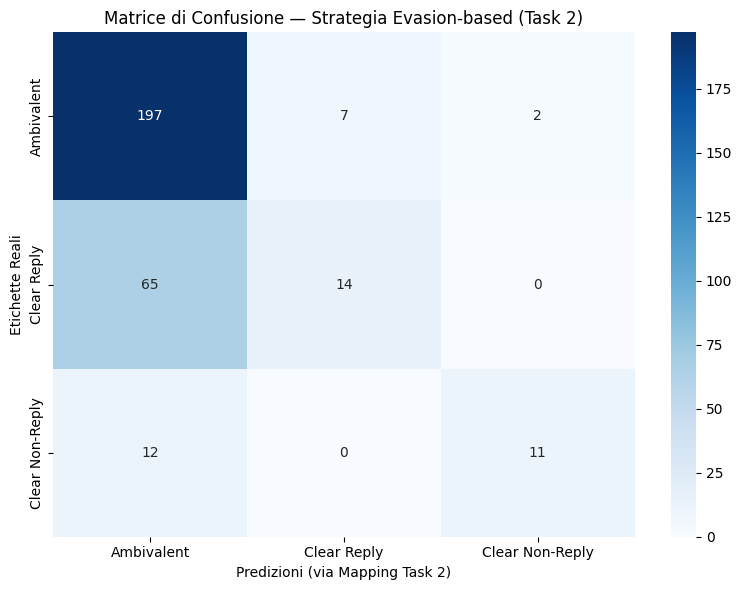


--- Distribuzione predizioni grezze (Task 2) ---
        Tecnica Task 2  Conteggio
0              General        254
1             Explicit         21
2              Dodging         14
3  Declining to answer          7
4     Claims ignorance          6
5        Clarification          6

Salvataggio risultati in corso nella directory: ../results/task2/valutazione...
CSV salvato con successo: ../results/task2/valutazione/predizioni_test_set.csv


In [9]:
# ============================================================
# CELLA 6 — Valutazione e Grafici
# ============================================================

y_true_clarity = []
y_pred_clarity = []
y_true_raw_evasion = []
y_pred_raw_evasion = []

print(f"Valutazione su {len(test_dataset)} esempi...")

for i in tqdm(range(len(test_dataset))):
    esempio = test_dataset[i]

    # Etichetta reale (macro-categoria)
    y_true_clarity.append(str(esempio.get('clarity_label', '')).strip())
    y_true_raw_evasion.append(get_true_evasion_label(esempio))

    # Predizione → normalizzazione → mapping
    tecnica, clarity, raw = predici_evasione(esempio)
    y_pred_raw_evasion.append(tecnica)
    y_pred_clarity.append(clarity)

# Classification Report pre-mapping sulle 9 classi Task 2
print("\n" + "=" * 60)
print("REPORT PRE-MAPPING — TASK 2 (9 CLASSI EVASION)")
print("=" * 60)
if any(label in LABELS_9_CLASSI for label in y_true_raw_evasion):
    print(classification_report(
        y_true_raw_evasion,
        y_pred_raw_evasion,
        labels=LABELS_9_CLASSI,
        digits=3,
        zero_division=0,
    ))
else:
    print("Etichette vere Task 2 non disponibili nel test set: report 9-classi saltato.")
    print("Distribuzione predizioni pre-mapping:")
    print(pd.Series(y_pred_raw_evasion).value_counts())

# Classification Report (3 cifre decimali)
print("\n" + "=" * 60)
print("REPORT FINALE — TASK 2 (EVASION → CLARITY)")
print("=" * 60)
print(classification_report(y_true_clarity, y_pred_clarity, labels=LABELS, digits=3))

# Matrice di Confusione
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true_clarity, y_pred_clarity, labels=LABELS)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predizioni (via Mapping Task 2)')
plt.ylabel('Etichette Reali')
plt.title('Matrice di Confusione — Strategia Evasion-based (Task 2)')
plt.tight_layout()

# Salvataggio Grafico
os.makedirs(RISULTATI_DIR, exist_ok=True)
percorso_grafico = os.path.join(RISULTATI_DIR, "matrice_confusione.png")
plt.savefig(percorso_grafico, bbox_inches='tight', dpi=300)
plt.show()

# Distribuzione delle tecniche di evasione predette
df_raw = pd.Series(y_pred_raw_evasion).value_counts().reset_index()
df_raw.columns = ['Tecnica Task 2', 'Conteggio']

print("\n--- Distribuzione predizioni grezze (Task 2) ---")
print(df_raw)

# Salvataggio Predizioni in CSV
print(f"\nSalvataggio risultati in corso nella directory: {RISULTATI_DIR}...")
df_risultati = pd.DataFrame({
    'Domanda': [ex.get('interview_question', '') for ex in test_dataset],
    'Risposta_Politico': [ex.get('interview_answer', '') for ex in test_dataset],
    'Vero_Task1_Clarity': y_true_clarity,
    'Vero_Task2_Evasion': y_true_raw_evasion,
    'Predetto_Task2_Evasion': y_pred_raw_evasion,
    'Predetto_Task1_Clarity': y_pred_clarity
})

percorso_csv = os.path.join(RISULTATI_DIR, "predizioni_test_set.csv")
df_risultati.to_csv(percorso_csv, index=False)
print(f"CSV salvato con successo: {percorso_csv}")

In [10]:
# ============================================================
# CELLA 7 — Diagnostica etichette & distribuzioni
# ============================================================

import os
import pandas as pd
from collections import Counter

print("\n=== Diagnostica Task 2 ===")
print("Test set evasion_label (da dataset):")
print(dict(Counter(test_dataset["evasion_label"])))

csv_path = os.path.join(RISULTATI_DIR, "predizioni_test_set.csv")
if not os.path.exists(csv_path):
    print(f"CSV non trovato: {csv_path}")
else:
    df = pd.read_csv(csv_path)
    print("\nNull in Vero_Task2_Evasion:", df["Vero_Task2_Evasion"].isna().sum())
    print("Vero_Task2_Evasion (value_counts):")
    print(df["Vero_Task2_Evasion"].fillna("<NA>").value_counts())
    print("Predetto_Task2_Evasion (value_counts):")
    print(df["Predetto_Task2_Evasion"].value_counts())

    if {"Vero_Task1_Clarity", "Predetto_Task1_Clarity"}.issubset(df.columns):
        y_true = df["Vero_Task1_Clarity"].astype(str).str.strip()
        y_pred = df["Predetto_Task1_Clarity"].astype(str).str.strip()
        print("\nMacro report (da CSV):")
        print(classification_report(y_true, y_pred, labels=LABELS, digits=3))


=== Diagnostica Task 2 ===
Test set evasion_label (da dataset):
{'': 308}

Null in Vero_Task2_Evasion: 0
Vero_Task2_Evasion (value_counts):
Vero_Task2_Evasion
Explicit               79
Dodging                61
Implicit               61
General                55
Deflection             22
Declining to answer    11
Claims ignorance        8
Partial/half-answer     7
Clarification           4
Name: count, dtype: int64
Predetto_Task2_Evasion (value_counts):
Predetto_Task2_Evasion
General                254
Explicit                21
Dodging                 14
Declining to answer      7
Claims ignorance         6
Clarification            6
Name: count, dtype: int64

Macro report (da CSV):
                 precision    recall  f1-score   support

     Ambivalent      0.719     0.956     0.821       206
    Clear Reply      0.667     0.177     0.280        79
Clear Non-Reply      0.846     0.478     0.611        23

       accuracy                          0.721       308
      macro avg    